In [11]:
import pandas as pd

# 1. Load the excel file
file_path = "Document from singhlink4.xlsx"


orders = pd.read_excel(file_path, sheet_name='orders')
items = pd.read_excel(file_path, sheet_name='order_items')
payments = pd.read_excel(file_path, sheet_name='order_payments')
reviews = pd.read_excel(file_path, sheet_name='order_reviews')
customers = pd.read_excel(file_path, sheet_name='customers')
products = pd.read_excel(file_path, sheet_name='products')
sellers = pd.read_excel(file_path, sheet_name='sellers')
geo = pd.read_excel(file_path, sheet_name='geolocation')
category_trans = pd.read_excel(file_path, sheet_name='category_translation')

print("Fixing dates in orders table")
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

print("Fixing dates in reviews")
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

print("Handling geolocation duplicates")
geo_clean = geo.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

print("Loading and cleaning done!")

Fixing dates in orders table
Fixing dates in reviews
Handling geolocation duplicates
Loading and cleaning done!


In [12]:
print("Step 1: Fixing Product Categories")
products = pd.merge(products, category_trans, on='product_category_name', how='left')
# Fill missing english translations with 'unknown'
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')

print("Step 2: Filtering and Cleaning Orders")
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
# Drop rows where the actual delivery date is missing
delivered_orders.dropna(subset=['order_delivered_customer_date', 'order_purchase_timestamp'], inplace=True)

print("Step 3: Calculating Important Metrics")
delivered_orders['actual_delivery_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']).dt.days
delivered_orders['estimated_delivery_days'] = (delivered_orders['order_estimated_delivery_date'] - delivered_orders['order_purchase_timestamp']).dt.days
# Positive value = delayed, Negative value = delivered early
delivered_orders['delay_in_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_estimated_delivery_date']).dt.days

print("Step 4: Building the Master DataFrame")
master_df = pd.merge(delivered_orders, customers, on='customer_id', how='inner')
master_df = pd.merge(master_df, reviews, on='order_id', how='left')
master_df = pd.merge(master_df, items, on='order_id', how='left')
master_df = pd.merge(master_df, products, on='product_id', how='left')

# Group payments by order_id so we don't duplicate order rows
order_payments_sum = payments.groupby('order_id')['payment_value'].sum().reset_index()
master_df = pd.merge(master_df, order_payments_sum, on='order_id', how='left')

print("Master Data Cleaning & Merging Done! Final shape:", master_df.shape)

Step 1: Fixing Product Categories
Step 2: Filtering and Cleaning Orders
Step 3: Calculating Important Metrics
Step 4: Building the Master DataFrame
Master Data Cleaning & Merging Done! Final shape: (110840, 36)


Analyzing Marketplace Performance Over Time...


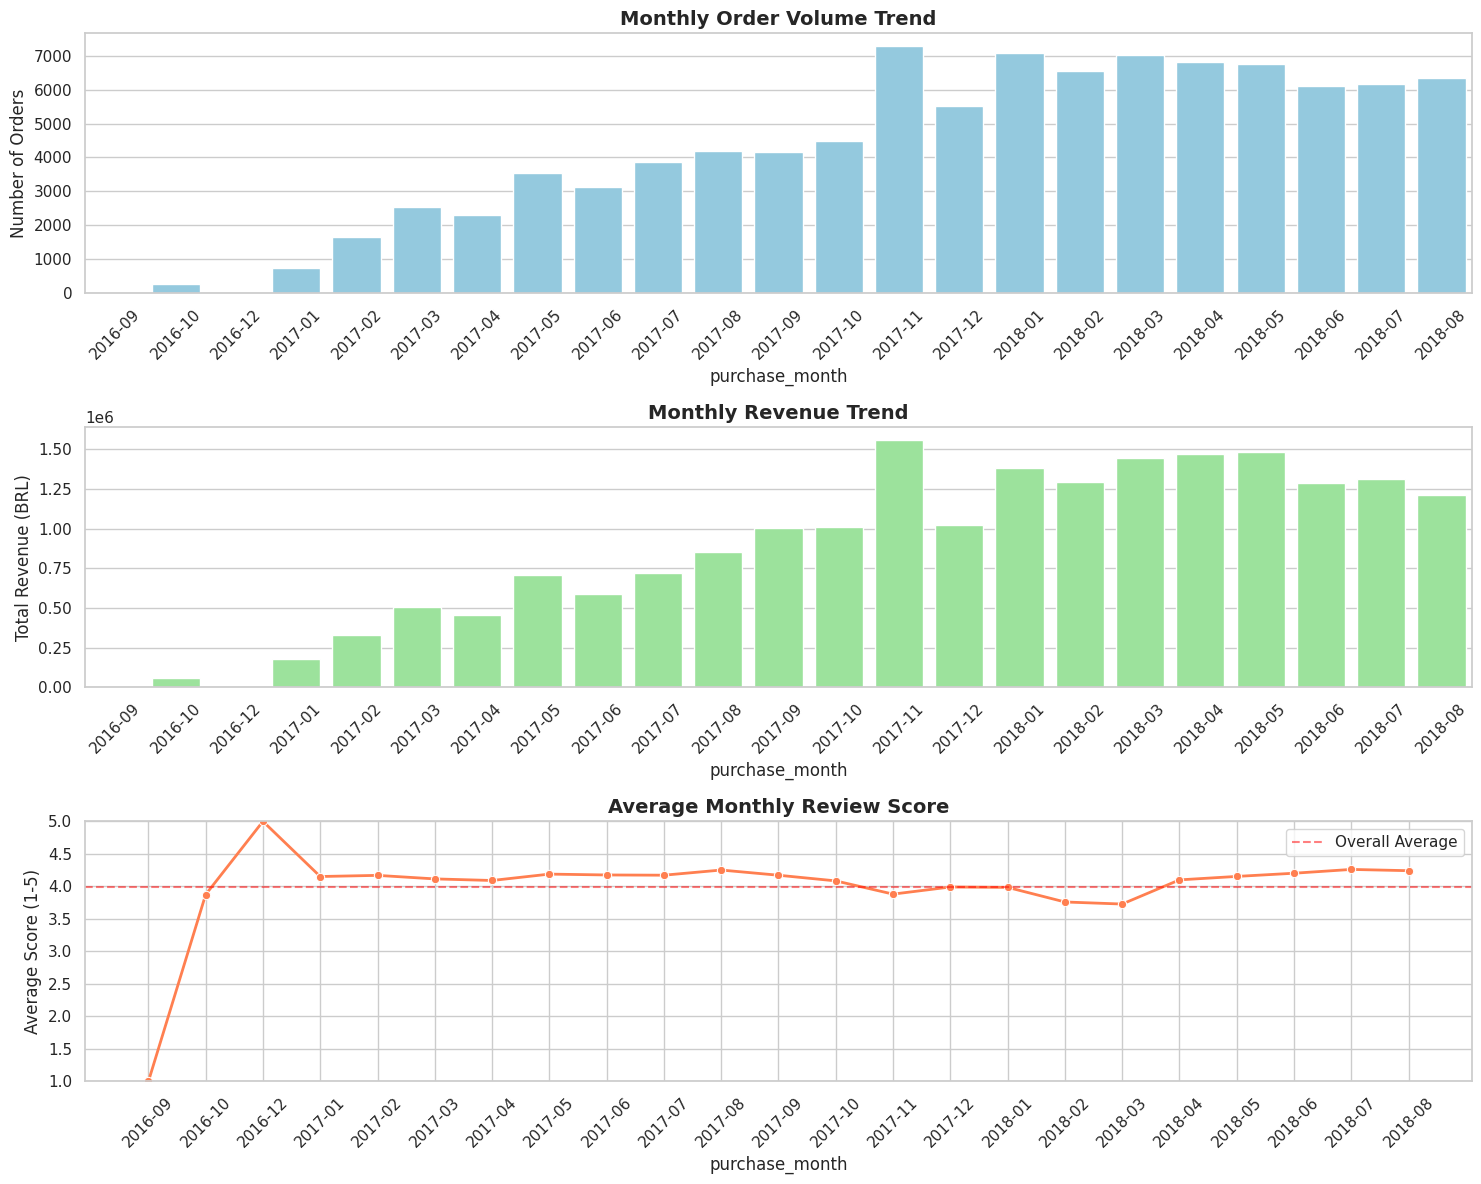

Calculation and plotting complete!


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Analyzing Marketplace Performance Over Time...")

# 1. Extract Year-Month for grouping
# .dt.to_period('M') makes '2017-09-15' into '2017-09'
master_df['purchase_month'] = master_df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# 2. Group by month to get our metrics
# unique orders for volume, sum of payments for revenue, mean of scores for satisfaction
monthly_stats = master_df.groupby('purchase_month').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('payment_value', 'sum'),
    avg_review_score=('review_score', 'mean')
).reset_index()

# Sort chronologically just in case
monthly_stats = monthly_stats.sort_values('purchase_month')

# 3. Plotting the trends (Brute force: 3 subplots for clarity)
plt.figure(figsize=(15, 12))
sns.set_theme(style="whitegrid")

# Plot A: Order Volume
plt.subplot(3, 1, 1)
sns.barplot(data=monthly_stats, x='purchase_month', y='total_orders', color='skyblue')
plt.title('Monthly Order Volume Trend', fontsize=14, fontweight='bold')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

# Plot B: Revenue Trend
plt.subplot(3, 1, 2)
sns.barplot(data=monthly_stats, x='purchase_month', y='total_revenue', color='lightgreen')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue (BRL)')
plt.xticks(rotation=45)

# Plot C: Review Scores
plt.subplot(3, 1, 3)
sns.lineplot(data=monthly_stats, x='purchase_month', y='avg_review_score', marker='o', color='coral', linewidth=2)
plt.title('Average Monthly Review Score', fontsize=14, fontweight='bold')
plt.ylabel('Average Score (1-5)')
plt.ylim(1, 5) # Score is out of 5
plt.xticks(rotation=45)
plt.axhline(y=monthly_stats['avg_review_score'].mean(), color='red', linestyle='--', alpha=0.5, label='Overall Average')
plt.legend()

plt.tight_layout()
plt.show()

print("Calculation and plotting complete!")

Analyzing Delivery Performance vs Satisfaction...


/tmp/ipykernel_2992/1770318448.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


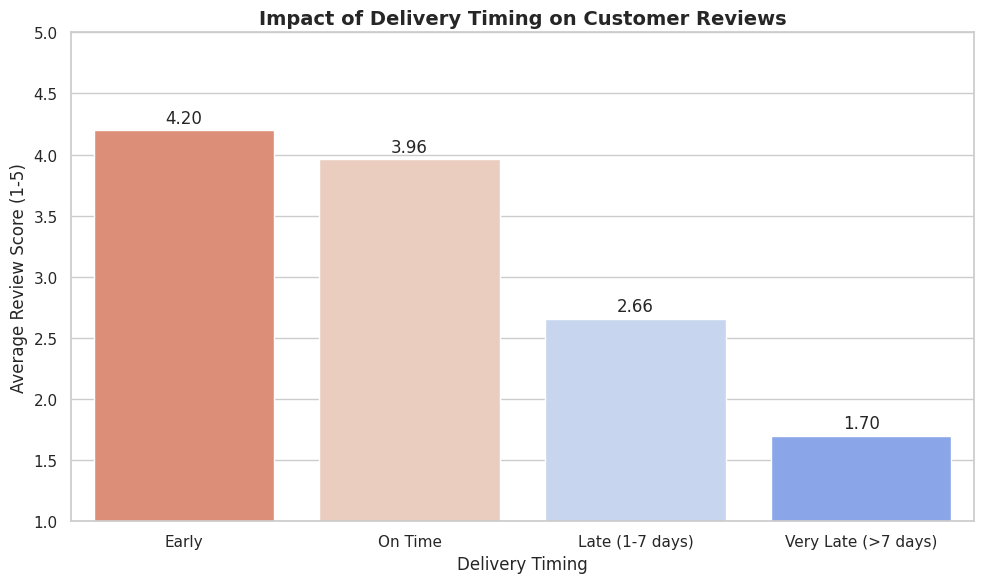


Top 5 States with the Highest Average Delay (in days):
customer_state
AL    -8.740139
MA    -9.996273
SE   -10.002667
ES   -10.658318
BA   -10.978672
Name: delay_in_days, dtype: float64


In [14]:
print("Analyzing Delivery Performance vs Satisfaction...")

# 1. Create a simple function to categorize deliveries
def categorize_delivery(delay):
    if pd.isna(delay):
        return 'Unknown'
    elif delay < 0:
        return 'Early'
    elif delay == 0:
        return 'On Time'
    elif delay <= 7:
        return 'Late (1-7 days)'
    else:
        return 'Very Late (>7 days)'

# Apply the function to our master dataframe
master_df['delivery_status'] = master_df['delay_in_days'].apply(categorize_delivery)

# 2. Group by delivery status to find the average review score
delivery_impact = master_df.groupby('delivery_status').agg(
    total_orders=('order_id', 'nunique'),
    avg_review_score=('review_score', 'mean')
).reset_index()

# Filter out 'Unknown' for a cleaner graph
delivery_impact = delivery_impact[delivery_impact['delivery_status'] != 'Unknown']

# 3. Plotting the results
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Define logical order for the x-axis
status_order = ['Early', 'On Time', 'Late (1-7 days)', 'Very Late (>7 days)']

ax = sns.barplot(
    data=delivery_impact,
    x='delivery_status',
    y='avg_review_score',
    order=status_order,
    palette='coolwarm_r' # Red for late, Blue for early
)

plt.title('Impact of Delivery Timing on Customer Reviews', fontsize=14, fontweight='bold')
plt.ylabel('Average Review Score (1-5)', fontsize=12)
plt.xlabel('Delivery Timing', fontsize=12)
plt.ylim(1, 5)

# Add exact numbers on top of the bars for maximum impact in your presentation
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

# Let's also quickly check if geography makes delivery worse
print("\nTop 5 States with the Highest Average Delay (in days):")
state_delays = master_df.groupby('customer_state')['delay_in_days'].mean().sort_values(ascending=False).head(5)
print(state_delays)

Analyzing Geographic Patterns & Logistics Inequality...


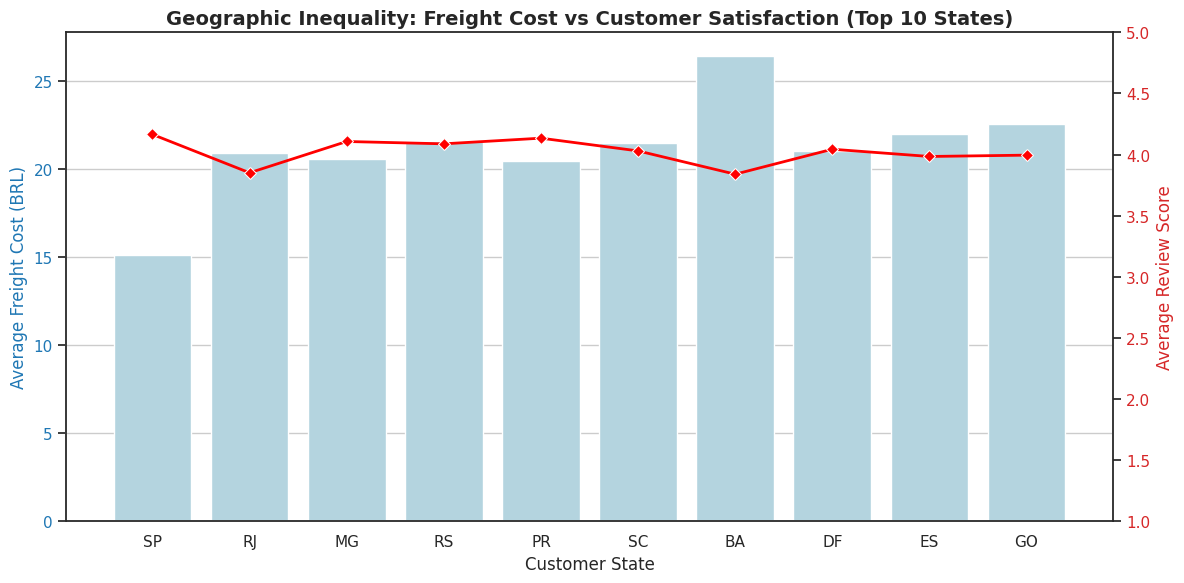


Seller Concentration:
Percentage of sellers in SP (São Paulo): 59.74%


In [15]:
print("Analyzing Geographic Patterns & Logistics Inequality...")

# 1. Group data by Customer State
# We want order volume, average freight cost, average delay, and review score per state
state_performance = master_df.groupby('customer_state').agg(
    total_orders=('order_id', 'nunique'),
    avg_freight_cost=('freight_value', 'mean'),
    avg_delay=('delay_in_days', 'mean'),
    avg_review_score=('review_score', 'mean')
).reset_index()

# 2. Sort by total orders to see the biggest markets first
state_performance = state_performance.sort_values('total_orders', ascending=False)

# Let's take the Top 10 states by order volume for a clean visualization
top_10_states = state_performance.head(10)

# 3. Plotting: A dual-axis chart showing Freight Cost vs Review Score across Top 10 States
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_theme(style="white")

# Axis 1: Bar chart for Average Freight Cost
color = 'tab:blue'
ax1.set_xlabel('Customer State', fontsize=12)
ax1.set_ylabel('Average Freight Cost (BRL)', color=color, fontsize=12)
sns.barplot(data=top_10_states, x='customer_state', y='avg_freight_cost', color='lightblue', ax=ax1)
ax1.tick_params(axis='y', labelcolor=color)

# Axis 2: Line chart for Average Review Score on the same graph
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Average Review Score', color=color, fontsize=12)
sns.lineplot(data=top_10_states, x='customer_state', y='avg_review_score', color='red', marker='D', linewidth=2, ax=ax2)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(1, 5)

plt.title('Geographic Inequality: Freight Cost vs Customer Satisfaction (Top 10 States)', fontsize=14, fontweight='bold')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

# 4. Let's do a quick calculation on where Sellers are located
print("\nSeller Concentration:")
seller_states = sellers['seller_state'].value_counts().head(5)
print(f"Percentage of sellers in SP (São Paulo): {(seller_states.iloc[0] / len(sellers) * 100):.2f}%")

Analyzing Product Category Performance...
Platform Average Review Score across categories: 4.08


/tmp/ipykernel_2992/2823343372.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


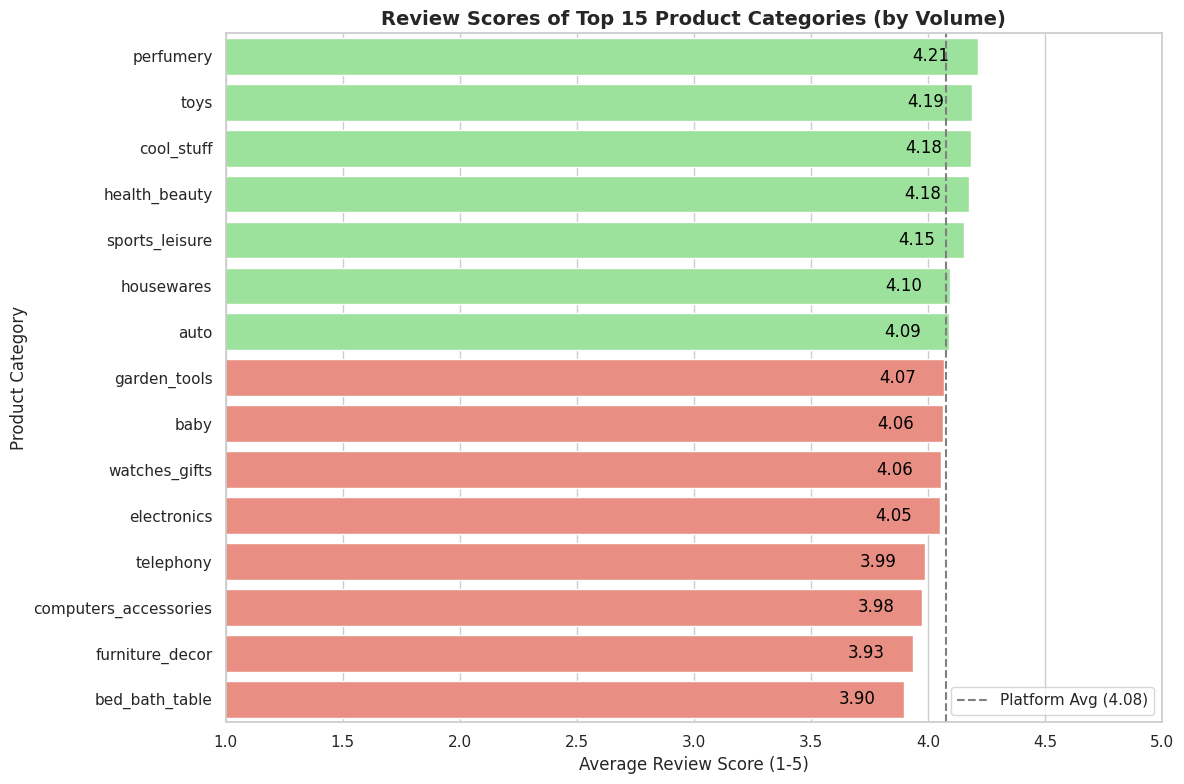


The weakest major category is 'bed_bath_table' with an average score of 3.90


In [16]:
print("Analyzing Product Category Performance...")

# 1. Group data by English Product Category
category_perf = master_df.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'nunique'),
    avg_order_value=('payment_value', 'mean'), # average amount spent per order
    avg_review_score=('review_score', 'mean')
).reset_index()

# Drop 'unknown' categories if any exist for cleaner analysis
category_perf = category_perf[category_perf['product_category_name_english'] != 'unknown']

# 2. Find the platform average review score to compare against
platform_avg_score = category_perf['avg_review_score'].mean()
print(f"Platform Average Review Score across categories: {platform_avg_score:.2f}")

# 3. Sort by volume to get the top 15 most popular categories
top_15_categories = category_perf.sort_values('total_orders', ascending=False).head(15)

# 4. Sort these top 15 by review score to see the best and worst performers among popular items
top_15_sorted_by_score = top_15_categories.sort_values('avg_review_score', ascending=False)

# 5. Plotting: Horizontal Bar Chart showing Review Scores of Top Categories
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Create a color palette: Green if above average, Red if below average
colors = ['lightgreen' if score > platform_avg_score else 'salmon' for score in top_15_sorted_by_score['avg_review_score']]

ax = sns.barplot(
    data=top_15_sorted_by_score,
    y='product_category_name_english',
    x='avg_review_score',
    palette=colors
)

plt.axvline(x=platform_avg_score, color='grey', linestyle='--', label=f'Platform Avg ({platform_avg_score:.2f})')
plt.title('Review Scores of Top 15 Product Categories (by Volume)', fontsize=14, fontweight='bold')
plt.xlabel('Average Review Score (1-5)')
plt.ylabel('Product Category')
plt.xlim(1, 5)
plt.legend()

# Add values on the bars
for i, p in enumerate(ax.patches):
    ax.text(p.get_width() - 0.2, p.get_y() + p.get_height() / 2.,
            f'{p.get_width():.2f}',
            ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

# Quick check on the worst-performing large category
worst_cat = top_15_sorted_by_score.iloc[-1]
print(f"\nThe weakest major category is '{worst_cat['product_category_name_english']}' with an average score of {worst_cat['avg_review_score']:.2f}")

Analyzing Payment Behavior & Installments...


/tmp/ipykernel_2992/211976717.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_summary, x='payment_type', y='avg_payment_value', palette='viridis', ax=axes[0])


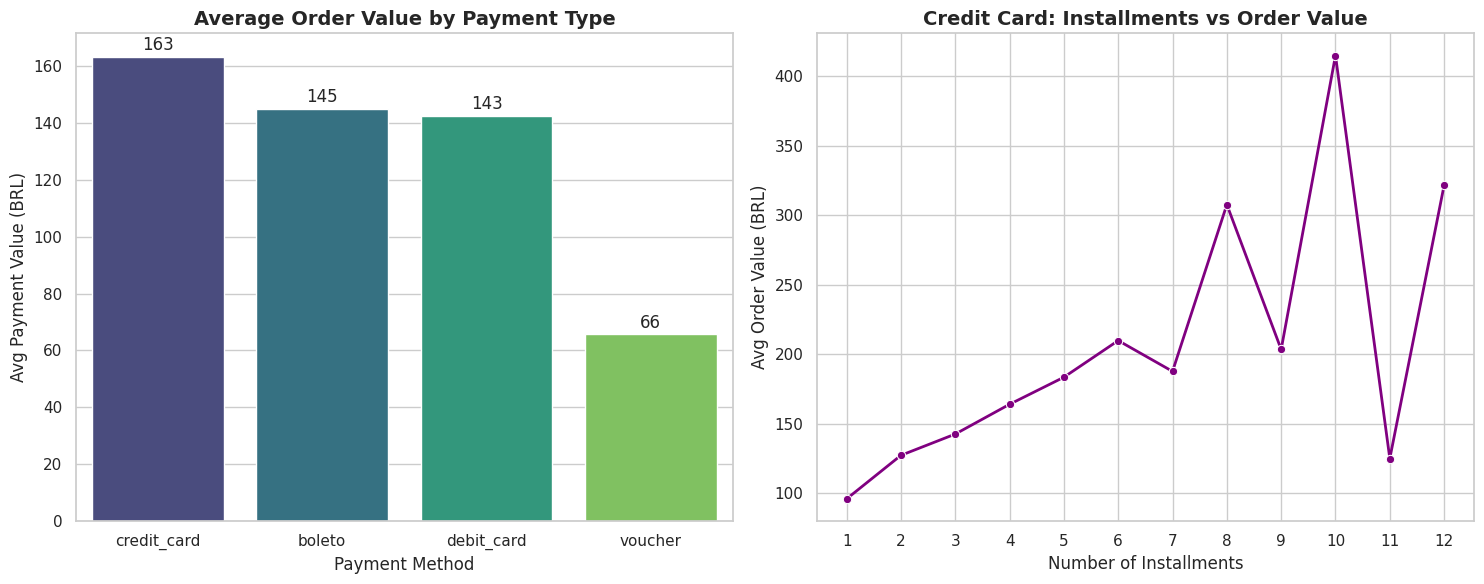


Quick Check: Average Review Score by Payment Type:
payment_type  avg_review_score
  debit_card          4.156901
 credit_card          4.072145
      boleto          4.071522
     voucher          3.986449


In [17]:
print("Analyzing Payment Behavior & Installments...")

# 1. Payment Type vs Average Order Value
payment_summary = payments.groupby('payment_type').agg(
    total_transactions=('order_id', 'count'),
    avg_payment_value=('payment_value', 'mean')
).reset_index()

# Drop 'not_defined' for clean charts
payment_summary = payment_summary[payment_summary['payment_type'] != 'not_defined']
payment_summary = payment_summary.sort_values('avg_payment_value', ascending=False)

# 2. Does payment type affect Review Scores?
# Merge payments with reviews directly
pay_rev = pd.merge(payments, reviews[['order_id', 'review_score']], on='order_id', how='inner')
pay_rev_summary = pay_rev.groupby('payment_type').agg(
    avg_review_score=('review_score', 'mean')
).reset_index().sort_values('avg_review_score', ascending=False)

# 3. Installments vs Order Value (Focusing on Credit Cards)
cc_payments = payments[payments['payment_type'] == 'credit_card']
installment_summary = cc_payments.groupby('payment_installments').agg(
    avg_order_value=('payment_value', 'mean'),
    transaction_count=('order_id', 'count')
).reset_index()

# Filter out weird installment numbers (keep 1 to 12 for standard EMIs)
installment_summary = installment_summary[(installment_summary['payment_installments'] >= 1) &
                                          (installment_summary['payment_installments'] <= 12)]

# 4. Plotting the story (2 side-by-side charts)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")

# Plot A: Order Value by Payment Type
sns.barplot(data=payment_summary, x='payment_type', y='avg_payment_value', palette='viridis', ax=axes[0])
axes[0].set_title('Average Order Value by Payment Type', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Avg Payment Value (BRL)')
axes[0].set_xlabel('Payment Method')

# Add values on bars
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.0f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')

# Plot B: Installments vs Avg Order Value
sns.lineplot(data=installment_summary, x='payment_installments', y='avg_order_value', marker='o', color='purple', linewidth=2, ax=axes[1])
axes[1].set_title('Credit Card: Installments vs Order Value', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Avg Order Value (BRL)')
axes[1].set_xlabel('Number of Installments')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

# Print the review scores check
print("\nQuick Check: Average Review Score by Payment Type:")
print(pay_rev_summary[pay_rev_summary['payment_type'] != 'not_defined'].to_string(index=False))

Performing Root Cause Analysis for Low Reviews...


/tmp/ipykernel_2992/321263070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=root_cause, x='review_sentiment', y='avg_delay_vs_estimate', palette=colors, ax=axes[0])
/tmp/ipykernel_2992/321263070.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=root_cause, x='review_sentiment', y='avg_total_delivery_time', palette=colors, ax=axes[1])
/tmp/ipykernel_2992/321263070.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=root_cause, x='review_sentiment', y='avg_freight_cost', palette=colors, ax=axes[2])


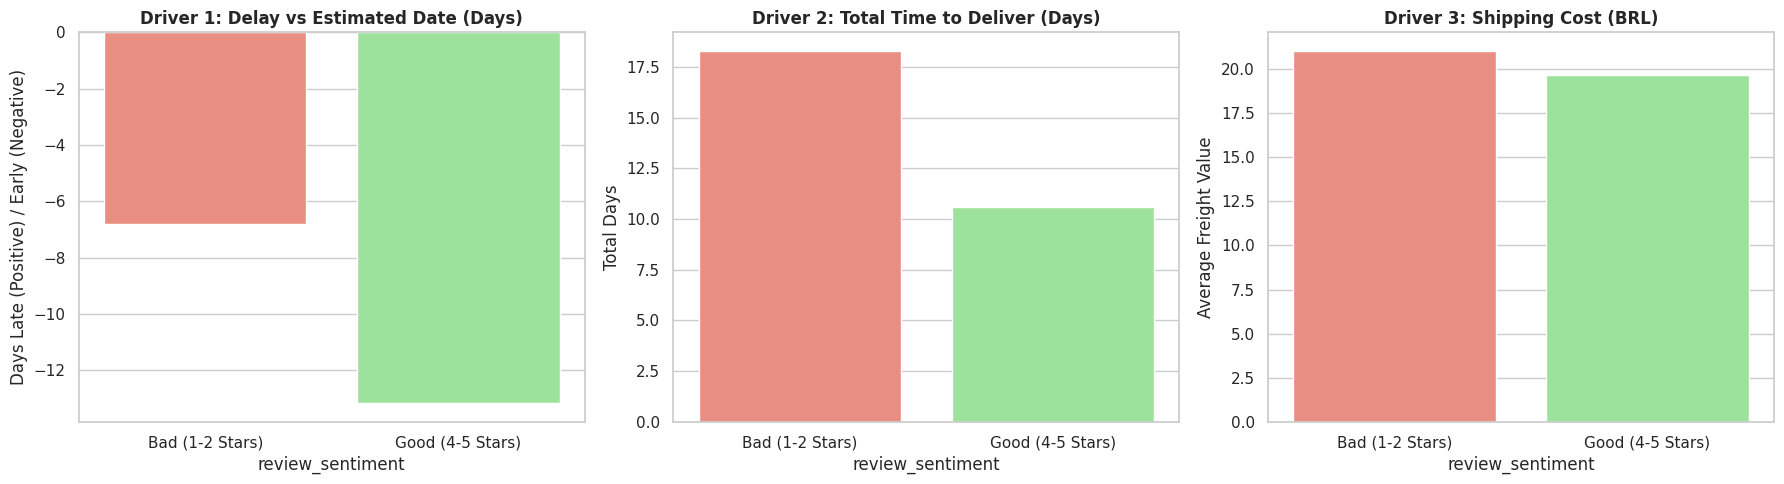


Insight: Bad reviews are delivered on average -6.8 days late, whereas Good reviews are delivered 13.2 days EARLY.


In [18]:
print("Performing Root Cause Analysis for Low Reviews...")

# 1. Segmenting the data into Good, Bad, and Neutral reviews
def categorize_sentiment(score):
    if pd.isna(score):
        return 'Unknown'
    elif score <= 2:
        return 'Bad (1-2 Stars)'
    elif score >= 4:
        return 'Good (4-5 Stars)'
    else:
        return 'Neutral (3 Stars)'

master_df['review_sentiment'] = master_df['review_score'].apply(categorize_sentiment)

# Filter out Neutral/Unknown for a stark contrast
polar_reviews = master_df[master_df['review_sentiment'].isin(['Bad (1-2 Stars)', 'Good (4-5 Stars)'])]

# 2. Calculating the metrics that might cause frustration
root_cause = polar_reviews.groupby('review_sentiment').agg(
    avg_delay_vs_estimate=('delay_in_days', 'mean'), # primary driver
    avg_total_delivery_time=('actual_delivery_days', 'mean'),
    avg_freight_cost=('freight_value', 'mean') # secondary driver
).reset_index()

# 3. Plotting the Root Causes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")
colors = ['salmon', 'lightgreen'] # Red for Bad, Green for Good

# Plot A: Delay vs Estimate
sns.barplot(data=root_cause, x='review_sentiment', y='avg_delay_vs_estimate', palette=colors, ax=axes[0])
axes[0].set_title('Driver 1: Delay vs Estimated Date (Days)', fontweight='bold')
axes[0].set_ylabel('Days Late (Positive) / Early (Negative)')

# Plot B: Total Delivery Time
sns.barplot(data=root_cause, x='review_sentiment', y='avg_total_delivery_time', palette=colors, ax=axes[1])
axes[1].set_title('Driver 2: Total Time to Deliver (Days)', fontweight='bold')
axes[1].set_ylabel('Total Days')

# Plot C: Freight Cost
sns.barplot(data=root_cause, x='review_sentiment', y='avg_freight_cost', palette=colors, ax=axes[2])
axes[2].set_title('Driver 3: Shipping Cost (BRL)', fontweight='bold')
axes[2].set_ylabel('Average Freight Value')

plt.tight_layout()
plt.show()

# Quick calculation to show the exact difference
bad_delay = root_cause[root_cause['review_sentiment'] == 'Bad (1-2 Stars)']['avg_delay_vs_estimate'].values[0]
good_delay = root_cause[root_cause['review_sentiment'] == 'Good (4-5 Stars)']['avg_delay_vs_estimate'].values[0]
print(f"\nInsight: Bad reviews are delivered on average {bad_delay:.1f} days late, whereas Good reviews are delivered {abs(good_delay):.1f} days EARLY.")